<a href="https://colab.research.google.com/github/joplus2/MPA-MLF/blob/main/project/MPA-MLF_projekt_pytorch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
import re
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from sklearn.model_selection import train_test_split
from PIL import Image
import copy

# kontrola GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"učení na: {device}")

učení na: cuda


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
if ( not os.path.exists("/content/x_train_local/")):

  !cp "/content/drive/MyDrive/MLF_projekt_dataset/x_train.zip" "/content/"

  !mkdir -p "/content/x_train_local/"

  !unzip -q "/content/x_train.zip" -d "/content/x_train_local/"

  !ls -1 "/content/x_train_local/" | wc -l

if ( not os.path.exists("/content/x_test_local/")):

  !cp "/content/drive/MyDrive/MLF_projekt_dataset/x_test.zip" "/content/"

  !mkdir -p "/content/x_test_local/"

  !unzip -q "/content/x_test.zip" -d "/content/x_test_local/"

  !ls -1 "/content/x_test_local/" | wc -l

9227
3955


In [4]:
class RadarDataset(Dataset):
    def __init__(self, dataframe, img_dir, transform=None, is_test=False):
        self.dataframe = dataframe
        self.img_dir = img_dir
        self.transform = transform
        self.is_test = is_test

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        img_name = self.dataframe.iloc[idx]['filename']
        img_path = os.path.join(self.img_dir, img_name)

        # převod do RGB
        image = Image.open(img_path).convert('RGB')

        if self.transform:
            image = self.transform(image)

        if self.is_test:
            return image, img_name
        else:
            label = self.dataframe.iloc[idx]['target']
            return image, label

# načtení štítků
BASE_DIR = '/content/drive/MyDrive/MLF_projekt_dataset/'
CSV_PATH = os.path.join(BASE_DIR, 'y_train_v2.csv')
df_labels = pd.read_csv(CSV_PATH)
df_labels['filename'] = "img_" + (df_labels['id'] + 1).astype(str) + '.png'
print(f"Celkem trénovacích dat: {len(df_labels)}")

Celkem trénovacích dat: 9227


In [5]:
# změna velikosti a převod na tenzor
data_transform = transforms.Compose([
    transforms.Resize((128, 113)),
    transforms.ToTensor(),
])

batch_size_var = 32

# rozdělení 80/20
train_df, valid_df = train_test_split(df_labels, test_size=0.2, random_state=42, stratify=df_labels['target'])

# instance datasetu
train_dataset = RadarDataset(train_df.reset_index(drop=True), '/content/x_train_local/', transform=data_transform)
valid_dataset = RadarDataset(valid_df.reset_index(drop=True), '/content/x_train_local/', transform=data_transform)

# dávkování dat
train_loader = DataLoader(train_dataset, batch_size=batch_size_var, shuffle=True, num_workers=2)
valid_loader = DataLoader(valid_dataset, batch_size=batch_size_var, shuffle=False, num_workers=2)

print(f"Batches pro trénink: {len(train_loader)}, pro validaci: {len(valid_loader)}")

Batches pro trénink: 231, pro validaci: 58


In [6]:
# stažení předtrénovaného modelu ResNet18
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# počet vstupů do poslední vrstvy
num_ftrs = model.fc.in_features

# přepis poslední vrstvy
model.fc = nn.Linear(num_ftrs, 4)

# výpočet na zařízení
model = model.to(device)

# váhování
class_weights = torch.tensor([1.0, 0.5, 0.8, 2.5]).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights)

# nastavení optimizeru
optimizer = optim.AdamW(model.parameters(), lr=0.0003, weight_decay=1e-4)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:01<00:00, 44.7MB/s]


In [7]:
num_epochs = 15
best_model_wts = copy.deepcopy(model.state_dict())
best_acc = 0.0

history = {'train_loss': [], 'valid_loss': [], 'train_acc': [], 'valid_acc': []}

for epoch in range(num_epochs):
    print(f'Epocha {epoch+1}/{num_epochs}')
    print('-' * 10)

    for phase in ['train', 'valid']:
        if phase == 'train':
            model.train()
            dataloader = train_loader
        else:
            model.eval()
            dataloader = valid_loader

        running_loss = 0.0
        running_corrects = 0

        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            with torch.set_grad_enabled(phase == 'train'):
                outputs = model(inputs)
                _, preds = torch.max(outputs, 1)
                loss = criterion(outputs, labels)

                if phase == 'train':
                    loss.backward()
                    optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)

        epoch_loss = running_loss / len(dataloader.dataset)
        # .item() převede tensor na klasické desetinné číslo
        epoch_acc = (running_corrects.double() / len(dataloader.dataset)).item()

        print(f'{phase.capitalize()} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

        # NOVÉ: Uložení dat do historie pro pozdější grafy
        history[f'{phase}_loss'].append(epoch_loss)
        history[f'{phase}_acc'].append(epoch_acc)

        if phase == 'valid':
            scheduler.step(epoch_loss)
            if epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())

    print()

print(f'Nejlepší val: {best_acc:4f}')
model.load_state_dict(best_model_wts)

Epocha 1/15
----------
Train Loss: 0.5049 Acc: 0.7815
Valid Loss: 0.4277 Acc: 0.8229

Epocha 2/15
----------
Train Loss: 0.2443 Acc: 0.9001
Valid Loss: 0.2316 Acc: 0.9280

Epocha 3/15
----------
Train Loss: 0.1637 Acc: 0.9344
Valid Loss: 0.2071 Acc: 0.9155

Epocha 4/15
----------
Train Loss: 0.1280 Acc: 0.9508
Valid Loss: 0.2110 Acc: 0.8954

Epocha 5/15
----------
Train Loss: 0.1085 Acc: 0.9581
Valid Loss: 0.1485 Acc: 0.9447

Epocha 6/15
----------
Train Loss: 0.0570 Acc: 0.9778
Valid Loss: 0.2386 Acc: 0.9150

Epocha 7/15
----------
Train Loss: 0.0678 Acc: 0.9744
Valid Loss: 0.1910 Acc: 0.9567

Epocha 8/15
----------
Train Loss: 0.0533 Acc: 0.9782
Valid Loss: 0.2647 Acc: 0.9225

Epocha 9/15
----------
Train Loss: 0.0408 Acc: 0.9843
Valid Loss: 0.2227 Acc: 0.9632

Epocha 10/15
----------
Train Loss: 0.0125 Acc: 0.9965
Valid Loss: 0.1205 Acc: 0.9642

Epocha 11/15
----------
Train Loss: 0.0041 Acc: 0.9985
Valid Loss: 0.1753 Acc: 0.9751

Epocha 12/15
----------
Train Loss: 0.0016 Acc: 0.99

<All keys matched successfully>

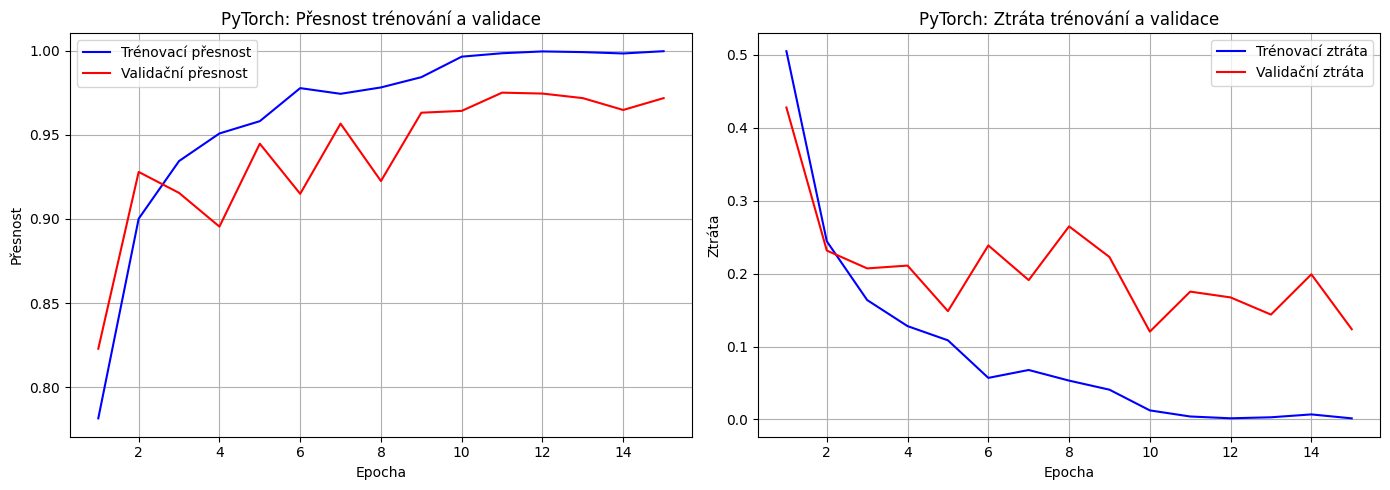

In [8]:
import matplotlib.pyplot as plt

epochs_range = range(1, num_epochs + 1)

plt.figure(figsize=(14, 5))

# přesnosti
plt.subplot(1, 2, 1)
plt.plot(epochs_range, history['train_acc'], 'b-', label='Trénovací přesnost')
plt.plot(epochs_range, history['valid_acc'], 'r-', label='Validační přesnost')
plt.title('PyTorch: Přesnost trénování a validace')
plt.xlabel('Epocha')
plt.ylabel('Přesnost')
plt.legend()
plt.grid(True)

# ztráty
plt.subplot(1, 2, 2)
plt.plot(epochs_range, history['train_loss'], 'b-', label='Trénovací ztráta')
plt.plot(epochs_range, history['valid_loss'], 'r-', label='Validační ztráta')
plt.title('PyTorch: Ztráta trénování a validace')
plt.xlabel('Epocha')
plt.ylabel('Ztráta')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


 Report klasifikace 
                precision    recall  f1-score   support

0 osob (Stroj)       0.99      1.00      0.99       293
       1 osoba       0.97      0.99      0.98       757
       2 osoby       0.97      0.97      0.97       601
       3 osoby       0.97      0.92      0.94       195

      accuracy                           0.98      1846
     macro avg       0.98      0.97      0.97      1846
  weighted avg       0.98      0.98      0.97      1846



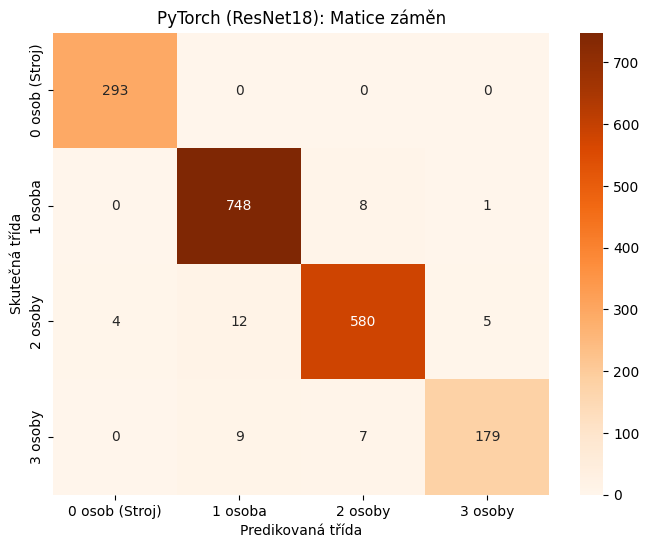

In [9]:
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

model.eval() # vyhodnocovací režim

y_true = []
y_pred = []

with torch.no_grad():
    for inputs, labels in valid_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)

        y_true.extend(labels.numpy())
        y_pred.extend(preds.cpu().numpy())

nazvy_trid = ['0 osob (Stroj)', '1 osoba', '2 osoby', '3 osoby']

print("\n Report klasifikace ")
print(classification_report(y_true, y_pred, target_names=nazvy_trid))

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=nazvy_trid, yticklabels=nazvy_trid)
plt.title('PyTorch (ResNet18): Matice záměn')
plt.ylabel('Skutečná třída')
plt.xlabel('Predikovaná třída')
plt.show()

In [11]:
TEST_DIR = '/content/x_test_local/'
test_files = [f for f in os.listdir(TEST_DIR) if f.endswith('.png')]

def extract_number(filename):
    match = re.search(r'\d+', filename)
    return int(match.group()) if match else 0

test_files.sort(key=extract_number)
test_df = pd.DataFrame({'filename': test_files})

test_dataset = RadarDataset(test_df, TEST_DIR, transform=data_transform, is_test=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

model.eval()
all_preds = []
all_ids = []

with torch.no_grad():
    for inputs, img_names in test_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        ids = [extract_number(name) - 1 for name in img_names]
        all_ids.extend(ids)

submission_df = pd.DataFrame({
    'id': all_ids,
    'target': all_preds
})

submission_df.to_csv('/content/submission_pytorch.csv', index=False)
print("Soubor vytvořen")

Soubor vytvořen
